In [15]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

# 4.1

In [29]:
if not os.path.exists('132736__ciccarelli__ocean-waves.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/132736__ciccarelli__ocean-waves.wav

--2026-05-19 18:11:14--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/132736__ciccarelli__ocean-waves.wav
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/132736__ciccarelli__ocean-waves.wav [following]
--2026-05-19 18:11:14--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/132736__ciccarelli__ocean-waves.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14286332 (14M) [application/octet-stream]
Saving to: ‘132736__ciccarelli__ocean-waves.wav’

132736__ciccarelli_ 100%[===================>]  13.62M  42.4MB/s    in 0.3s    

2026-

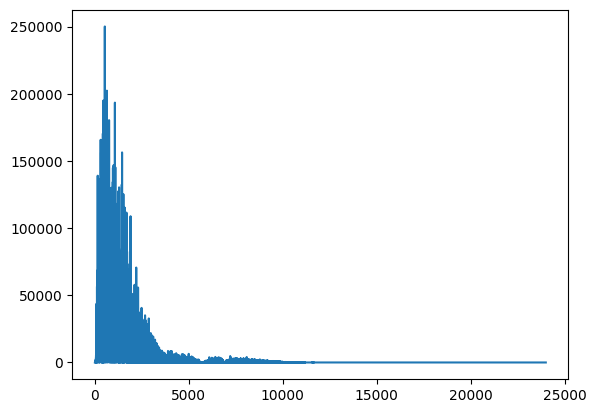

In [35]:
wave = thinkdsp.read_wave('132736__ciccarelli__ocean-waves.wav')
segment = wave.segment(start=3, duration=5)
segment.make_audio()

spectrum = segment.make_spectrum()
spectrum.plot_power()

Основная мощность сосредоточена в низких частотах, значит это красный или розовый шум

Возьмем шум через несколько секунд и наложим их друг на друга

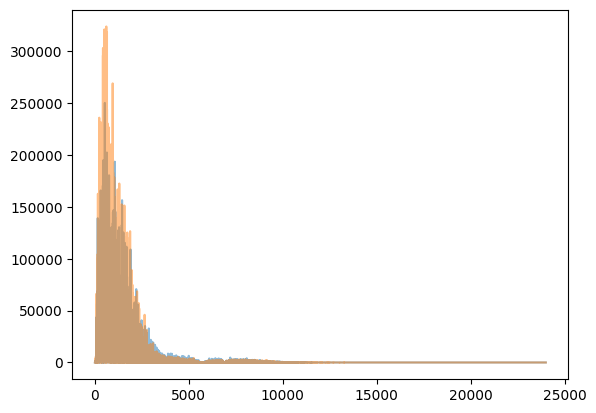

In [41]:
segment1 = wave.segment(start=3, duration=5)
segment2 = wave.segment(start=8, duration=10)
spectrum1 = segment1.make_spectrum()
spectrum2 = segment2.make_spectrum()
spectrum1.plot_power(alpha=0.5)
spectrum2.plot_power(alpha=0.5)

Общая структура во времени не изменяется

# 4.2

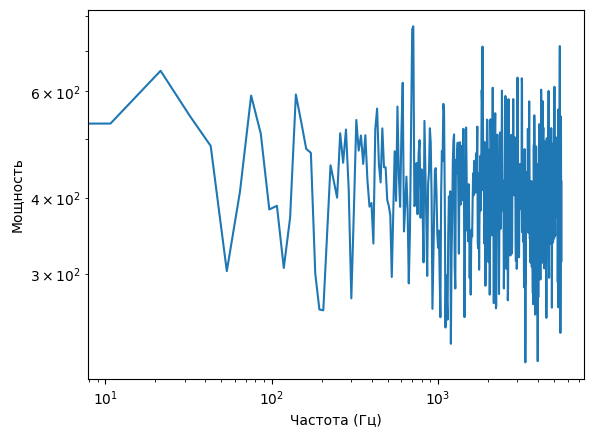

<Figure size 800x600 with 0 Axes>

In [47]:
import numpy as np

def bartlett_spectrum(wave, seg_length, overlap=0.5):
    """Оценка спектра мощности методом Бартлетта.

    wave - объект Wave
    seg_length - длина сегмента в отсчётах
    overlap - перекрытие (0..1)
    """
    step = int(seg_length * (1 - overlap))
    n_segments = (len(wave.ys) - seg_length) // step + 1
    sum_power = None

    for i in range(n_segments):
        start = i * step
        segment = wave.segment(start=start/len(wave.ys), duration=seg_length/wave.framerate)
        # Применяем окно Хэмминга для уменьшения утечки
        window = np.hamming(seg_length)
        segment.window(window)
        spectrum = segment.make_spectrum()
        power = spectrum.power
        if sum_power is None:
            sum_power = power
            freqs = spectrum.fs
        else:
            sum_power += power

    avg_power = sum_power / n_segments
    # Возвращаем объект Spectrum
    return thinkdsp.Spectrum(avg_power**0.5, freqs, wave.framerate)

# Пример: белый шум
white = thinkdsp.UncorrelatedGaussianNoise().make_wave(duration=2, framerate=11025)
bartlett_spec = bartlett_spectrum(white, seg_length=1024, overlap=0.5)
bartlett_spec.plot_power()
thinkplot.config(xlabel='Частота (Гц)', ylabel='Мощность', xscale='log', yscale='log')
thinkplot.show()

# 4.3

In [54]:
if not os.path.exists('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv

In [58]:
import pandas as pd

df = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv',
                 parse_dates=[0])
df

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-02,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-03,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-04,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-05,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2354,BTC,2020-03-22,5884.340133,6187.042146,6431.873162,5802.553402
2355,BTC,2020-03-23,6455.454688,5829.352511,6620.858253,5694.198299
2356,BTC,2020-03-24,6784.318011,6455.450650,6863.602196,6406.037439
2357,BTC,2020-03-25,6706.985089,6784.325204,6981.720386,6488.111885


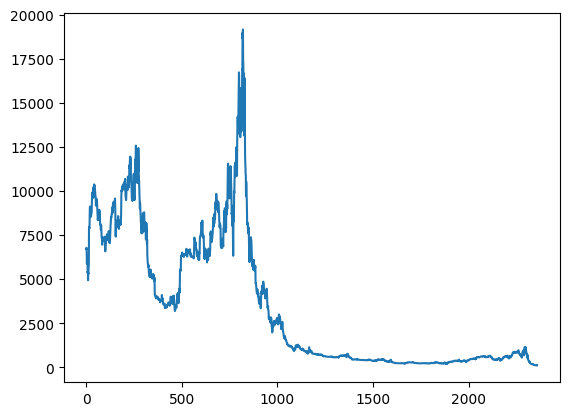

In [70]:
prices = df['Closing Price (USD)'].values[::-1]  # в хронологическом порядке
ts = df.index

# Создаём Wave с частотой кадров 1 (отсчёт в день)
wave = thinkdsp.Wave(prices, ts, framerate=1)
wave.plot()

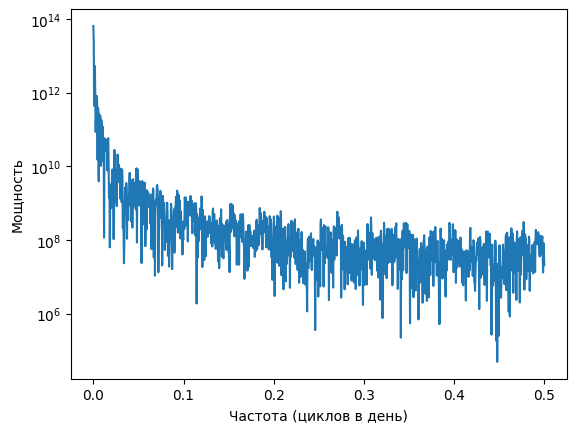

<Figure size 800x600 with 0 Axes>

In [71]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
thinkplot.config(xlabel='Частота (циклов в день)', ylabel='Мощность',
                 yscale='log')
thinkplot.show()

In [72]:
spectrum.estimate_slope()[0]

np.float64(-1.7332540936758916)

Степень для f порядка 1.7, что говорит о том, что это что-то близкое к красному, но все еще розовый шум

# 4.4

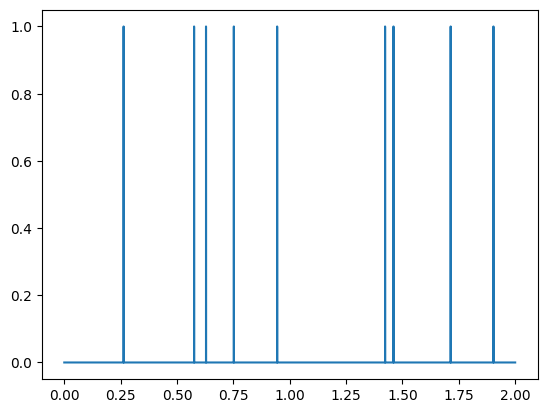

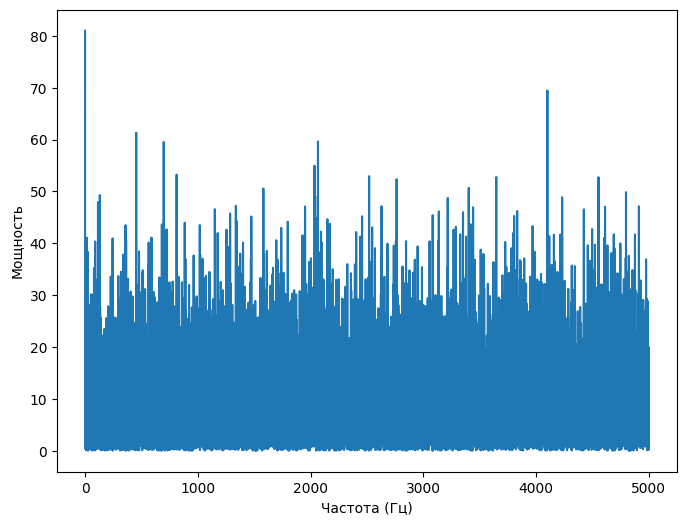

<Figure size 800x600 with 0 Axes>

In [80]:
import numpy as np

class UncorrelatedPoissonNoise(thinkdsp.Noise):
    """Некоррелированный пуассоновский шум."""
    def __init__(self, amp=1.0, rate=1.0):
        """
        amp: амплитуда (масштаб) – фактически будет максимальное значение
        rate: среднее число событий на выборку (λ)
        """
        self.amp = amp
        self.rate = rate

    def evaluate(self, ts):
        n = len(ts)
        # Генерируем выборки из распределения Пуассона
        counts = np.random.poisson(self.rate, n)
        ys = (counts / max(1, np.max(counts))) * self.amp
        return ys

# Генерация 2 секунд шума, частота 10 кГц, среднее 0.001 события на выборку (~10 щелчков/сек)
signal = UncorrelatedPoissonNoise(amp=1.0, rate=0.0005)
wave = signal.make_wave(duration=2, framerate=10000)
wave.normalize()
wave.plot()
thinkplot.show()

# Спектр мощности
spectrum = wave.make_spectrum()
spectrum.plot_power()
thinkplot.config(xlabel='Частота (Гц)', ylabel='Мощность')
thinkplot.show()

wave.make_audio()

# 4.5

/tmp/ipykernel_2686/2872733026.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


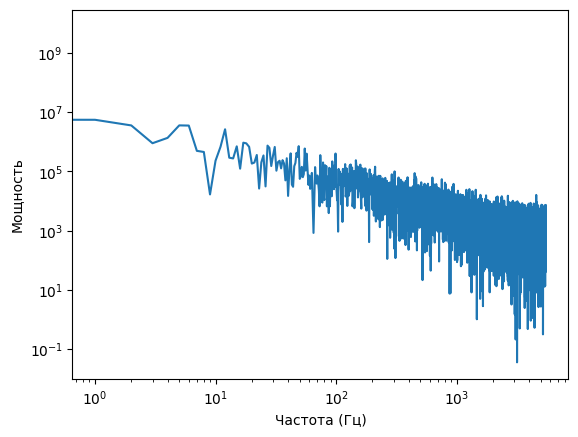

Наклон спектра: -1.02 (ожидается -1 для розового шума)


<Figure size 800x600 with 0 Axes>

In [87]:
import numpy as np

def voss(nrows, ncols=16):
    array = np.empty((nrows, ncols))
    array.fill(np.nan)
    array[0, :] = np.random.random(ncols)
    array[:, 0] = np.random.random(nrows)

    # the total number of changes is nrows
    n = nrows
    cols = np.random.geometric(0.5, n)
    cols[cols >= ncols] = 0
    rows = np.random.randint(nrows, size=n)
    array[rows, cols] = np.random.random(n)

    df = pd.DataFrame(array)
    df.fillna(method='ffill', axis=0, inplace=True)
    total = df.sum(axis=1)

    return total.values

# Генерация и проверка
ys = voss(11025)
wave = thinkdsp.Wave(ys)
spectrum = wave.make_spectrum()
spectrum.plot_power()
thinkplot.config(xlabel='Частота (Гц)', ylabel='Мощность', xscale='log', yscale='log')
thinkplot.show()

fs = spectrum.fs[1:]
power = spectrum.power[1:]
log_fs = np.log(fs)
log_power = np.log(power)
slope, intercept = np.polyfit(log_fs, log_power, 1)[:2]
print(f"Наклон спектра: {slope:.2f} (ожидается -1 для розового шума)")